# EN-3160 Image Processing and Machine Vision
## Assignment 01

* **Name:** Dharmakeerthi P.K.G.C.L.
* **Index Number:** 230140J


---



## Implimentation of the intensity transformation (Question 1)


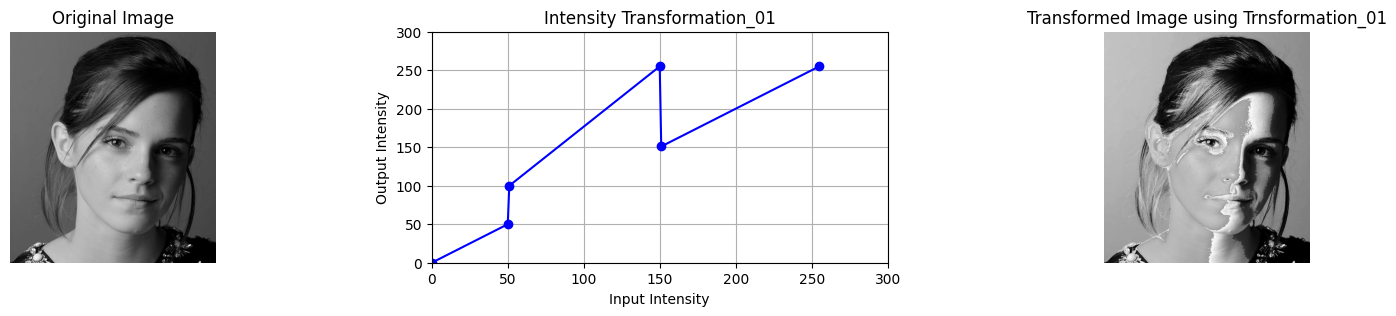

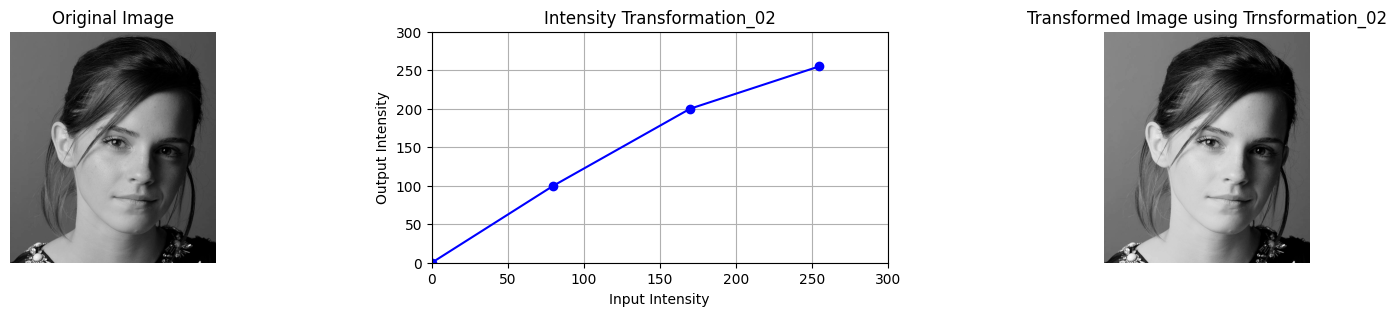

In [44]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv

breakpoints_1 = [[0,0], [50,50], [51,100], [150,255], [151,151],[255,255]]
breakpoints_2 = [[0, 0], [80, 100], [170, 200], [255, 255]]

x_coords_1 = [x[0] for x in breakpoints_1] # Extracting x-coordinates from the breakpoints_1
y_coords_1 = [x[1] for x in breakpoints_1] # Extracting y-coordinates from the breakpoints_1

x_coords_2 = [x[0] for x in breakpoints_2] # Extracting x-coordinates from the breakpoints_2
y_coords_2 = [x[1] for x in breakpoints_2] # Extracting y-coordinates from the breakpoints_2

def intensity_transform(im, breakpoints):
   
    # Separate into input (x) and output (y) coordinates
    x_coords = [x[0] for x in breakpoints]
    y_coords = [x[1] for x in breakpoints]

    # Apply numpy's linear interpolation
    # im.flatten() makes the 2D image a 1D array so interp can process it
    transformed_flat = np.interp(im.flatten(), x_coords, y_coords)
    
    # Reshape it back to the original image dimensions and ensure it's an 8-bit integer
    transformed_im = transformed_flat.reshape(im.shape).astype(np.uint8)
    
    return transformed_im

im = cv.imread("images\\q1.jpeg", cv.IMREAD_GRAYSCALE)
assert im is not None, "Image not found or unable to open."
transformed_imm_1 = intensity_transform(im, breakpoints_1)

fig , ax = plt.subplots(1,3,figsize = (20,3))
ax[0].imshow(im, cmap = 'gray', vmin = 0, vmax = 255)
ax[0].set_title('Original Image')
ax[0].axis('off')  # Hide axes for the original image


ax[1].plot(x_coords_1, y_coords_1, marker='o', color='blue', linestyle='-')
ax[1].set_title('Intensity Transformation_01')
ax[1].set_xlabel('Input Intensity')
ax[1].set_ylabel('Output Intensity')
ax[1].set_xlim([0, 300]) # Fixing the axes to standard 8-bit limits
ax[1].set_ylim([0, 300])
ax[1].grid(True) # Adding a grid helps visualize the breakpoints

ax[2].imshow(transformed_imm_1, cmap = 'gray', vmin = 0, vmax = 255)
ax[2].set_title('Transformed Image using Trnsformation_01')
ax[2].axis('off')  # Hide axes for the transformed image

transformed_imm_2 = intensity_transform(im, breakpoints_2)
fig , ax = plt.subplots(1,3,figsize = (20,3))

ax[0].imshow(im, cmap = 'gray', vmin = 0, vmax = 255)
ax[0].set_title('Original Image')
ax[0].axis('off')  # Hide axes for the original image

ax[1].plot(x_coords_2, y_coords_2, marker='o', color='blue', linestyle='-')
ax[1].set_title('Intensity Transformation_02')
ax[1].set_xlabel('Input Intensity')
ax[1].set_ylabel('Output Intensity')
ax[1].set_xlim([0, 300]) # Fixing the axes to standard 8-bit limits
ax[1].set_ylim([0, 300])
ax[1].grid(True) # Adding a grid helps visualize the breakpoints

ax[2].imshow(transformed_imm_2, cmap = 'gray', vmin = 0, vmax = 255)
ax[2].set_title('Transformed Image using Trnsformation_02')
ax[2].axis('off')  # Hide axes for the transformed image

plt.show()

## Question 2

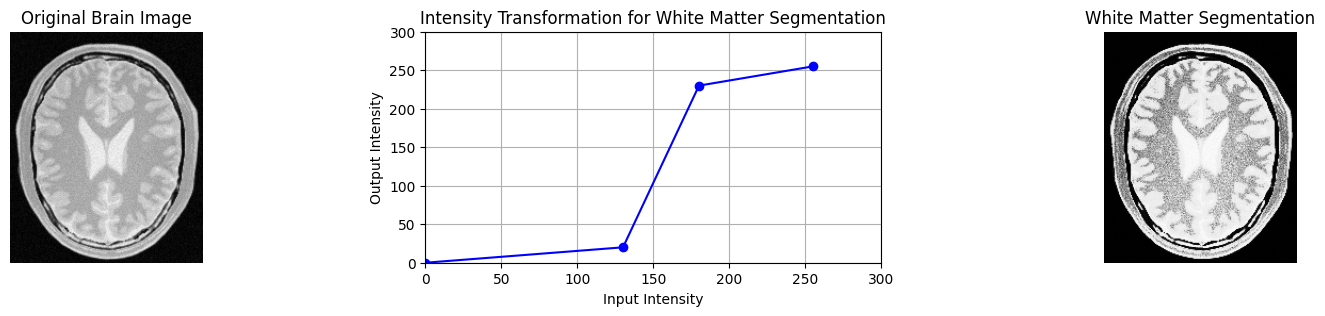

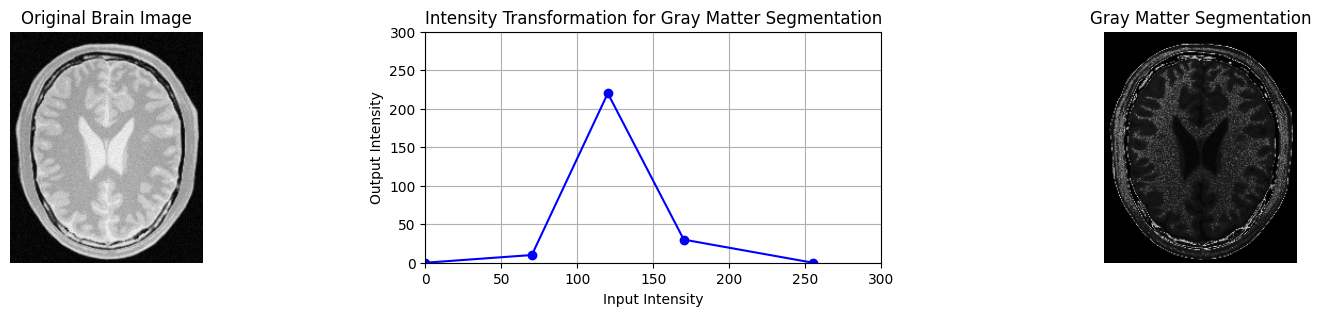

In [3]:
# Breakpoints targeting high intensities (White Matter)
wm_breakpoints = [
    [0, 0],
    [130, 20],   # Suppress CSF(Cerebral Spinal Fluid) and Gray Matter
    [180, 230],  # Steep stretch across White Matter range
    [255, 255]   # Max out bright regions
]
x_coords_wm = [x[0] for x in wm_breakpoints] # Extracting x-coordinates from the wm_breakpoints
y_coords_wm = [x[1] for x in wm_breakpoints] # Extracting y-coordinates from the wm_breakpoints

im_brain = cv.imread("images\\q2.jpeg", cv.IMREAD_GRAYSCALE)
wm_image = intensity_transform(im_brain, wm_breakpoints)

fig, ax = plt.subplots (1, 3, figsize=(20, 3))
ax[0].imshow(im_brain, cmap='gray', vmin=0, vmax=255)
ax[0].set_title('Original Brain Image')     
ax[0].axis('off')  # Hide axes for the original image

ax[1].plot(x_coords_wm, y_coords_wm, marker='o', color='blue', linestyle='-')
ax[1].set_title('Intensity Transformation for White Matter Segmentation')
ax[1].set_xlabel('Input Intensity')
ax[1].set_ylabel('Output Intensity')
ax[1].set_xlim([0, 300]) # Fixing the axes to standard 8-bit limits
ax[1].set_ylim([0, 300])
ax[1].grid(True) # Adding a grid helps visualize the breakpoints


ax[2].imshow(wm_image, cmap='gray', vmin=0, vmax=255)
ax[2].set_title('White Matter Segmentation')
ax[2].axis('off')  # Hide axes for the transformed image

plt.show()

# Breakpoints targeting mid intensities (Gray Matter)
gm_breakpoints = [
    [0, 0],
    [70, 10],    # Suppress dark background / CSF
    [120, 220],  # Steep stretch across Gray Matter range
    [170, 30],   # Drop bright White Matter to keep Gray Matter visually dominant
    [255, 0]
]

x_coords_gm = [x[0] for x in gm_breakpoints] # Extracting x-coordinates from the gm_breakpoints
y_coords_gm = [x[1] for x in gm_breakpoints] # Extracting y-coordinates from the gm_breakpoints

gm_image = intensity_transform(im_brain, gm_breakpoints)
fig, ax = plt.subplots (1, 3, figsize=(20, 3))
ax[0].imshow(im_brain, cmap='gray', vmin=0, vmax=255)
ax[0].set_title('Original Brain Image')     
ax[0].axis('off')  # Hide axes for the original image

ax[1].plot(x_coords_gm, y_coords_gm, marker='o', color='blue', linestyle='-')
ax[1].set_title('Intensity Transformation for Gray Matter Segmentation')
ax[1].set_xlabel('Input Intensity')
ax[1].set_ylabel('Output Intensity')
ax[1].set_xlim([0, 300]) # Fixing the axes to standard 8-bit limits
ax[1].set_ylim([0, 300])
ax[1].grid(True) # Adding a grid helps visualize the breakpoints


ax[2].imshow(gm_image, cmap='gray', vmin=0, vmax=255)
ax[2].set_title('Gray Matter Segmentation')
ax[2].axis('off')  # Hide axes for the transformed image

plt.show()




## Grey Matter (GM) vs. White Matter (WM) Image Analysis

In a T1-weighted brain MRI, different brain tissues have different brightness levels. **White Matter (WM)** usually appears brighter, **Grey Matter (GM)** appears in a medium gray range, and **Cerebrospinal Fluid (CSF)** appears darkest.

The histogram shows different intensity ranges for these tissues, although GM and WM can overlap slightly because some pixels contain a mixture of tissues. A **piecewise linear transformation** can be used to increase the contrast of GM or WM by stretching its intensity range. This makes the selected tissue easier to see while reducing the effect of the surrounding tissues.

Overall, this process improves the contrast between brain tissues and makes the boundaries between GM and WM clearer.


## Gamma correction to the L plane (Question 3)

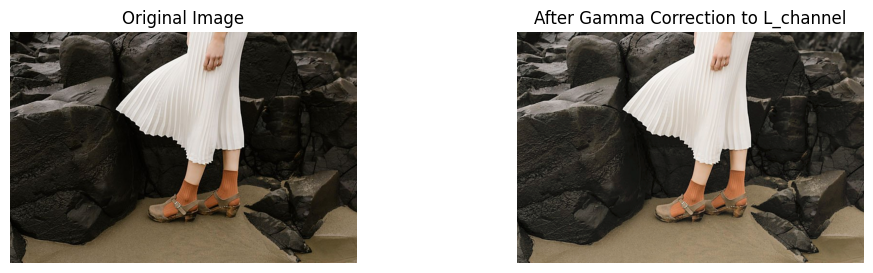

In [54]:
im = cv.imread("images\\3.jpeg")
im_LAB = cv.cvtColor(im,cv.COLOR_BGR2LAB)

fig,ax = plt.subplots(1,2,figsize = (12,3))
ax[0].imshow(cv.cvtColor(im,cv.COLOR_BGR2RGB))
ax[0].set_title('Original Image')
ax[0].axis('off')

l_plane, a_plane, b_plane = cv.split(im_LAB)
gamma = 0.75
lut = np.array([((i/255.0)**gamma)*255 for i in range(0,256)]).astype("uint8")
l_corrected = cv.LUT(l_plane,lut)

im_LAB_corrected = cv.merge((l_corrected,a_plane,b_plane))


ax[1].imshow(cv.cvtColor(im_LAB_corrected,cv.COLOR_LAB2RGB))
ax[1].set_title('After Gamma Correction to L_channel')
ax[1].axis('off')


plt.show()


The input image was converted to the **L*a*b*** color space using OpenCV's `cv.COLOR_BGR2LAB`. Gamma correction was then applied to the **L (lightness) channel** to adjust the overall brightness without significantly affecting the color information. A gamma value of **γ = 0.75** was selected to brighten the darker areas while maintaining the highlights.


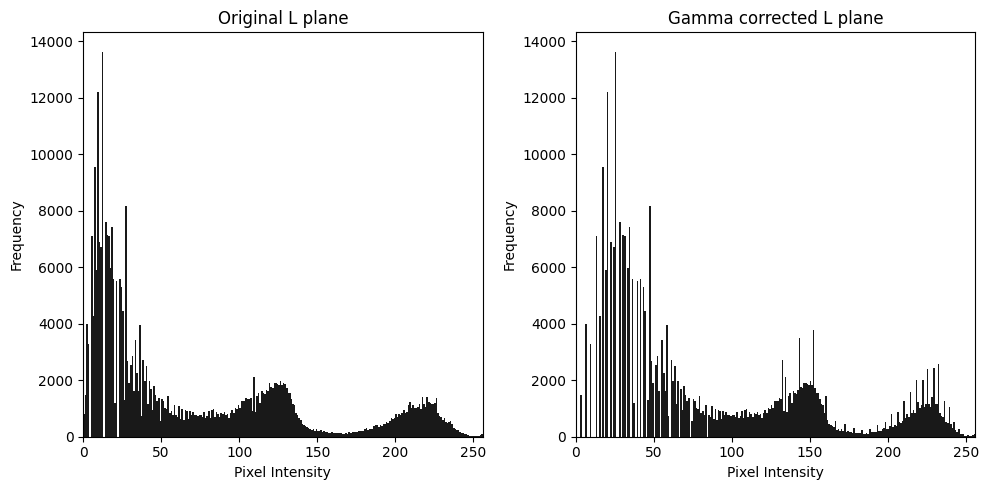

In [58]:
hist_orig = cv.calcHist([l_plane],[0],None,[256],[0,256])
hist_corr = cv.calcHist([l_corrected],[0],None,[256],[0,256])

L_flat = l_plane.flatten()
L_corrected_flat = l_corrected.flatten()

plt.figure(figsize=(10, 5))

# First subplot: Histogram of the first image
plt.subplot(1, 2, 1)
plt.hist(L_flat, bins=256, range=(0, 256), color='black', alpha=0.9)
plt.title('Original L plane')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.xlim([0, 256])

# Second subplot: Histogram of the second image
plt.subplot(1, 2, 2)
plt.hist(L_corrected_flat, bins=256, range=(0, 256), color='black', alpha=0.9)
plt.title('Gamma corrected L plane')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.xlim([0, 256])

plt.tight_layout() 
plt.show()

## Interpretation of Results

The histograms of the gamma-corrected image show a slight increase in noise. This is because gamma correction is a **non-linear transformation**. When applied to the L (lightness) channel, it can amplify small variations in pixel intensity. Since digital images contain discrete pixel values, the transformation can redistribute these values unevenly, resulting in **quantization effects**. This causes the pixel intensities to spread out and makes the histogram appear more irregular or noisy.


## Increasing the vibrance of an image (Question 4)

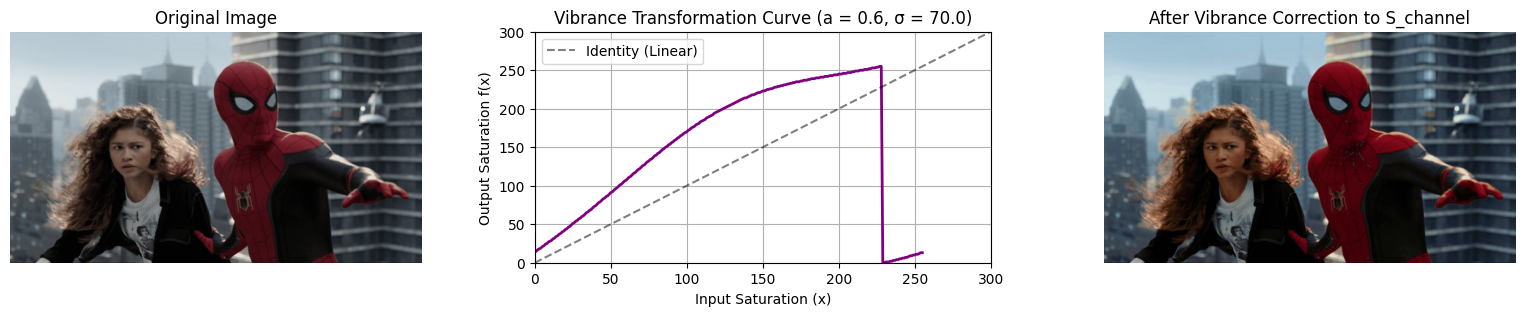

In [6]:
im  = cv.imread("images\\4.jpeg")
im_HSV = cv.cvtColor(im,cv.COLOR_BGR2HSV)

fig,ax = plt.subplots(1,3,figsize = (20,3))
ax[0].imshow(cv.cvtColor(im,cv.COLOR_BGR2RGB))
ax[0].set_title('Original Image')
ax[0].axis('off')

# Split into Hue, Saturation, and Value channels
H_plane, S_plane, V_plane = cv.split(im_HSV)

a = 0.6
sigma = 70.0

#Applicatin of the Gaussian function to the Saturation channel for enhancement
lut = np.array([(i + a * 128.0 * np.exp(-((i - 128.0) ** 2) / (2 * (sigma ** 2)))) for i in range(0,256)]).astype("uint8")
S_corrected = cv.LUT(S_plane,lut)

im_HSV_corrected = cv.merge((H_plane,S_corrected,V_plane))
x = np.arange(256, dtype=np.float32)

ax[1].plot(x, lut, color='purple', linewidth=2)
ax[1].plot([0, 300], [0, 300], 'k--', alpha=0.5, label='Identity (Linear)')
ax[1].set_title(f'Vibrance Transformation Curve (a = {a}, σ = {sigma})')
ax[1].set_xlabel('Input Saturation (x)')
ax[1].set_ylabel('Output Saturation f(x)')
ax[1].set_xlim([0, 300])
ax[1].set_ylim([0, 300])
ax[1].grid(True)
ax[1].legend()


ax[2].imshow(cv.cvtColor(im_HSV_corrected,cv.COLOR_HSV2RGB))
ax[2].set_title('After Vibrance Correction to S_channel')
ax[2].axis('off')

plt.show()


Parameter $a$ controls the strength of the saturation boost. Setting $a$ too high ($a > 0.8$) can cause clipping or unnatural color artifacts, while $a \approx 0.4 - 0.7$ gives a subtle, realistic vibrancy enhancement.So Hence by fine-tuning the image a = 0.6 was
selected as the best value.

## Histogram Equalization (Question 5)

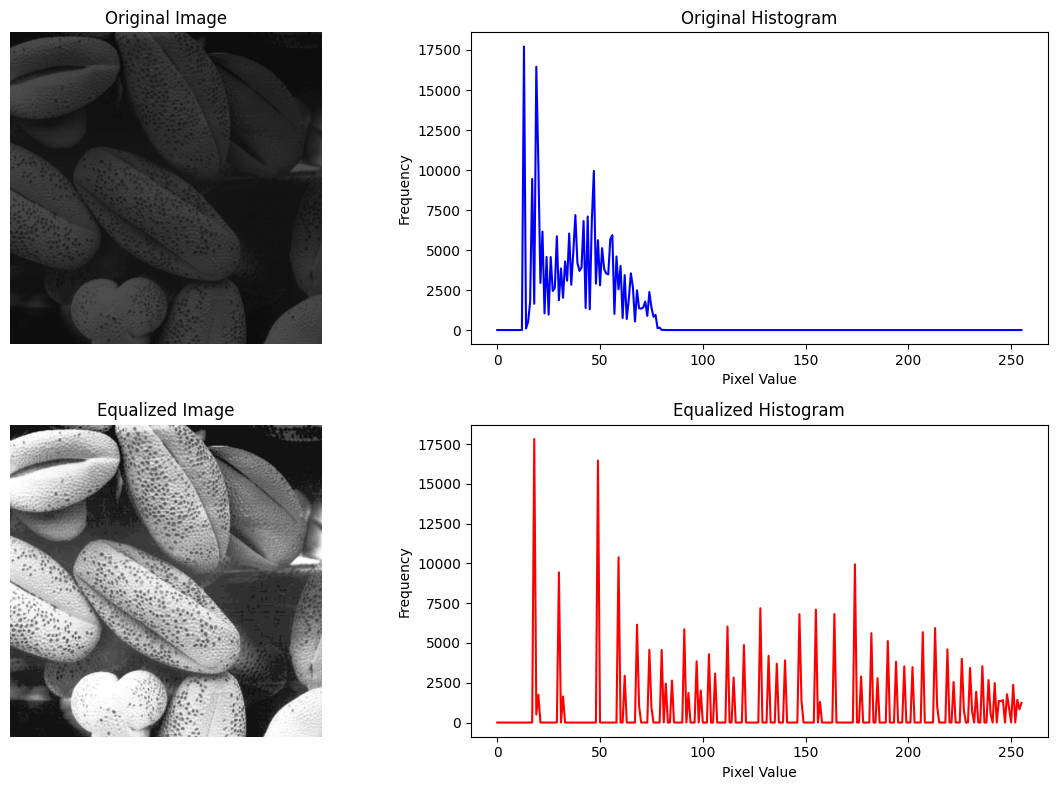

In [7]:
def custom_hitogram_equalization(im):
    hist, bins = np.histogram(im.flatten(), 256, [0, 256])

    cdf = np.cumsum(hist)/im.size  # Normalize the CDF to [0,1]
    lut = np.round(cdf * 255).astype(np.uint8)  # Scale to [0,255] and convert to uint8
    equalized_im = lut[im]

    return equalized_im

im = cv.imread("images\shells.tif", cv.IMREAD_GRAYSCALE)
equalized_im = custom_hitogram_equalization(im)
fig, ax = plt.subplots(2, 2, figsize=(12, 8))
ax[0][0].imshow(im, cmap='gray', vmin=0, vmax=255)
ax[0][0].set_title('Original Image')
ax[0][0].axis('off')  # Hide axes for the original image
ax[1][0].imshow(equalized_im, cmap='gray', vmin=0, vmax=255)
ax[1][0].set_title('Equalized Image')
ax[1][0].axis('off')  # Hide axes for the equalized image


hist_orig,bins = np.histogram(im.flatten(), bins=256, range=[0, 256])
hist_eq, bins= np.histogram(equalized_im.flatten(), bins=256, range=[0, 256])


ax[0][1].plot(hist_orig, color='blue')
ax[0][1].set_title('Original Histogram')
ax[0][1].set_xlabel('Pixel Value')
ax[0][1].set_ylabel('Frequency')

ax[1][1].plot(hist_eq, color='red')
ax[1][1].set_title('Equalized Histogram')
ax[1][1].set_xlabel('Pixel Value')
ax[1][1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()




## Interpretation of Results

As shown in the above graphs the histogram is more evenly spread after equalization, which improves the overall contrast of the image. However, the process also introduces some small amounts of quantization noise. The low-intensity peaks remain mostly unchanged after equalization.


## Question 6

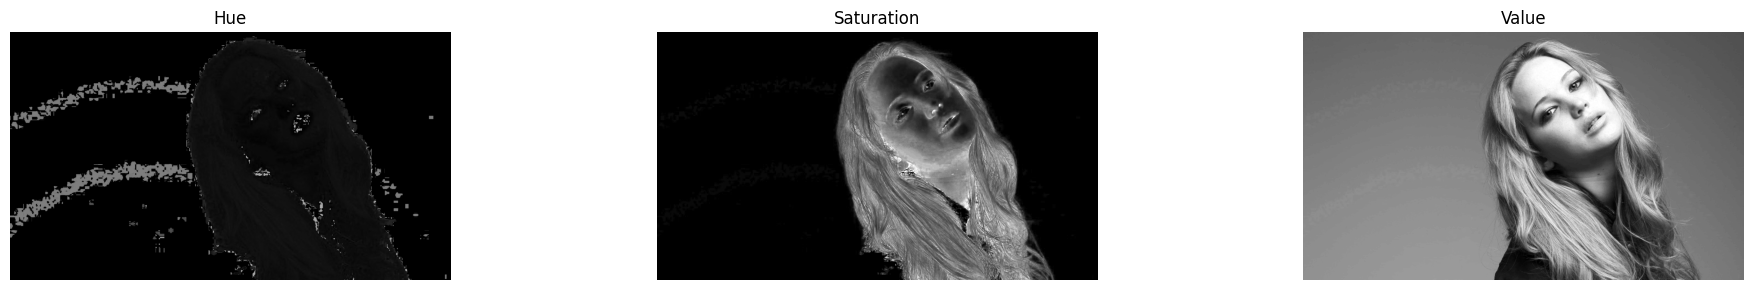

In [8]:
im = cv.imread("images\\7.jpeg")
im_HSV = cv.cvtColor(im,cv.COLOR_BGR2HSV)

H,S,V = cv.split(im_HSV)
fig,ax = plt.subplots(1,3,figsize=(20,3))

ax[0].imshow(H, cmap='gray', vmin=0, vmax=255)
ax[0].set_title('Hue')
ax[0].axis("off")
ax[1].imshow(S, cmap='gray', vmin=0, vmax=255)
ax[1].set_title('Saturation')
ax[1].axis("off")
ax[2].imshow(V, cmap='gray', vmin=0, vmax=255)
ax[2].set_title('Value')
ax[2].axis("off")

plt.tight_layout()
plt.show()

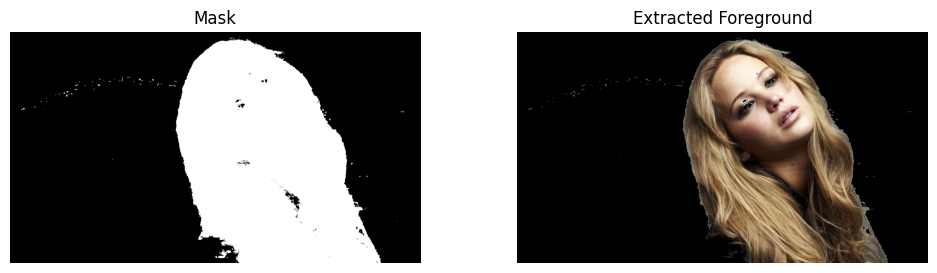

In [9]:

_, mask = cv.threshold(S, 12, 255, cv.THRESH_BINARY)

# Use bitwise_and to extract the foreground using the mask
foreground = cv.bitwise_and(im, im, mask=mask)

fig,ax = plt.subplots(1,2,figsize = (12,3))
ax[0].imshow(mask, cmap='gray', vmin=0, vmax=255)
ax[0].set_title('Mask')
ax[1].imshow(cv.cvtColor(foreground, cv.COLOR_BGR2RGB))
ax[1].set_title('Extracted Foreground')

for i in ax:
    i.axis('off')
plt.show()


Text(0, 0.5, 'Frequency')

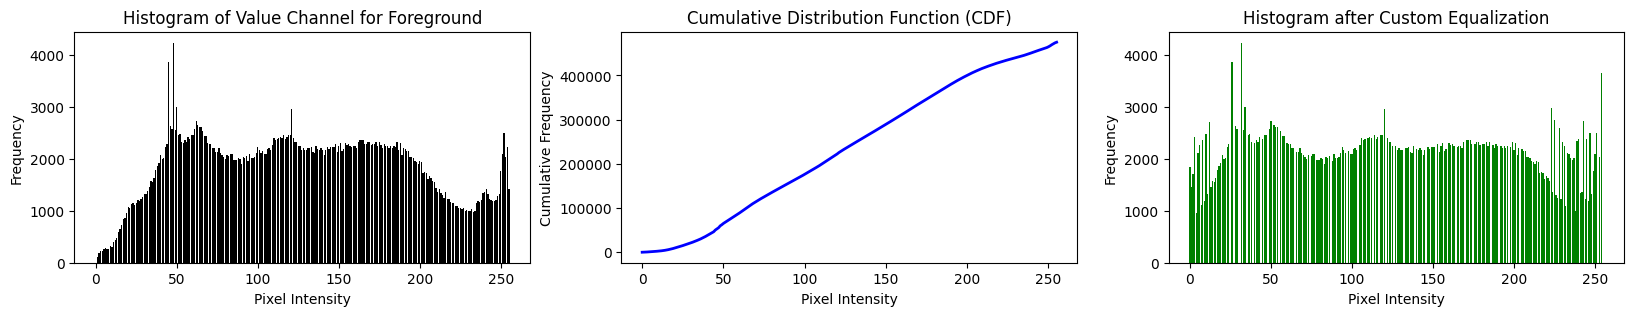

In [10]:
# Compute and plot the histogram of the Value (V) channel of the foreground
foreground_hsv = cv.cvtColor(foreground, cv.COLOR_BGR2HSV)
H_fg, S_fg, V_fg = cv.split(foreground_hsv)

# Calculate the histogram of the Value channel
hist = cv.calcHist([V_fg], [0], mask, [256], [0, 256])
cdf = hist.cumsum()

# Number of pixels
pixels = cdf[-1]

# Define transformation
t = np.array([(256-1)/(pixels)*cdf[k] for k in range(256)]).astype("uint8")

# Equalize
V_eq = t[V_fg]

# Calculate the histogram of the equalized Value channel
hist_equalized = cv.calcHist([V_eq], [0], mask, [256], [0, 256])


# Create an array for the x positions of the bars
x_positions = np.arange(256, dtype=np.float32)

fig,ax = plt.subplots(1,3,figsize = (20,3))
ax[0].bar(x_positions, hist.flatten(), color='black', linewidth=2)
ax[0].set_title('Histogram of Value Channel for Foreground')
ax[0].set_xlabel('Pixel Intensity')
ax[0].set_ylabel('Frequency')

ax[1].plot(x_positions, cdf.flatten(), color='blue', linewidth=2)
ax[1].set_title('Cumulative Distribution Function (CDF)')
ax[1].set_xlabel('Pixel Intensity')
ax[1].set_ylabel('Cumulative Frequency')    

ax[2].bar(x_positions, hist_equalized.flatten(), color='green', linewidth=2)
ax[2].set_title('Histogram after Custom Equalization')
ax[2].set_xlabel('Pixel Intensity')
ax[2].set_ylabel('Frequency')


### Interpretation of Results

The result of equalizing the foreground is shown. After applying histogram equalization, the image contains a greater number of dark pixels, as observed by comparing above Figures. This effect can also be seen in the output image.

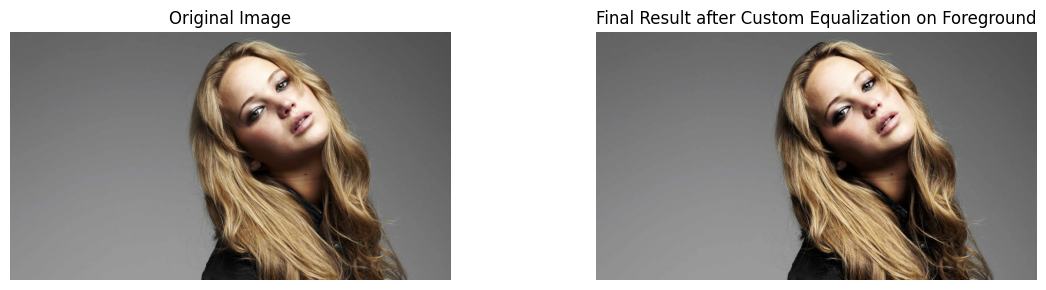

In [11]:
merged = cv.merge([H_fg,S_fg,V_eq])
modified_foreground = cv.cvtColor(merged,cv.COLOR_HSV2RGB)

background = cv.bitwise_and(im, im, mask=cv.bitwise_not(mask))
result = cv.add(cv.cvtColor(background, cv.COLOR_BGR2RGB), modified_foreground)

fig,ax = plt.subplots(1,2,figsize = (12,3))
ax[0].imshow(cv.cvtColor(im, cv.COLOR_BGR2RGB))
ax[0].set_title('Original Image')
ax[0].axis('off')
ax[1].imshow(result)
ax[1].set_title('Final Result after Custom Equalization on Foreground') 
ax[1].axis('off')

plt.tight_layout()
plt.show()

## Question 07


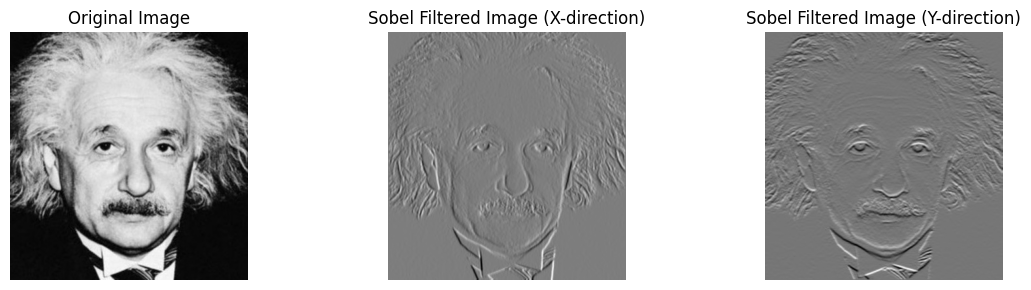

In [12]:
einstein = cv.imread("images\\6.jpeg",cv.IMREAD_GRAYSCALE)
assert einstein is not None, "Image not found or unable to open."

sobel_x = np.array([[1,0,-1],[0,0,0],[2,0,-2]])
sobel_y = np.array([[1,0,2],[0,0,0],[-1,0,-2]])

sobel_x_filtered= cv.filter2D(einstein, cv.CV_64F,sobel_x)
sobel_y_filtered= cv.filter2D(einstein, cv.CV_64F, sobel_y)

fig,ax = plt.subplots(1,3,figsize = (12,3))
ax[0].imshow(einstein, cmap = 'gray')
ax[0].set_title('Original Image')
ax[0].axis('off')  # Hide axes for the original image
ax[1].imshow(sobel_x_filtered, cmap = 'gray')
ax[1].set_title('Sobel Filtered Image (X-direction)')
ax[1].axis('off')  # Hide axes for the filtered image
ax[2].imshow(sobel_y_filtered, cmap = 'gray')
ax[2].set_title('Sobel Filtered Image (Y-direction)')
ax[2].axis('off')  # Hide axes for the filtered image   

plt.tight_layout()
plt.show()


In [13]:
def apply_filter(image, filter):
    [rows, columns] = np.shape(image) # Get rows and columns of the image
    filtered_image = np.zeros(shape=(rows, columns)) # Create empty image
    
    for i in range(rows - 2):
        for j in range(columns - 2): # Process 2D convolution
            value = np.sum(np.multiply(filter, image[i:i + 3, j:j + 3])) 
            filtered_image[i + 1, j + 1] = value
    
    return filtered_image

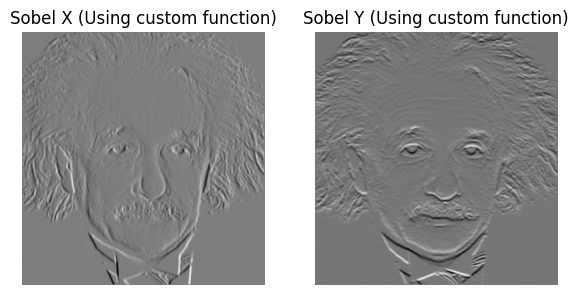

In [14]:
# Apply the Sobel filter in the X direction
sobel_x_filtered = apply_filter(einstein, sobel_x)

# Apply the Sobel filter in the Y direction
sobel_y_filtered = apply_filter(einstein, sobel_y)

# Create the figure for plotting
fig, ax = plt.subplots(1, 2, figsize=(6, 3))

ax[0].imshow(sobel_x_filtered, cmap='gray')
ax[0].set_title('Sobel X (Using custom function)')
ax[0].axis("off")
ax[1].imshow(sobel_y_filtered, cmap='gray')
ax[1].set_title('Sobel Y (Using custom function)')
ax[1].axis("off")

plt.tight_layout()
plt.show()


[]

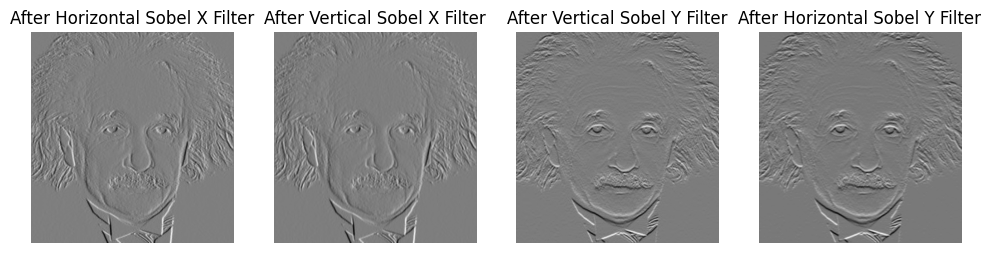

In [15]:
# Sobel x filter seperated
sobel_x_vertical = np.array([[1], [2], [1]])
sobel_x_horizontal = np.array([[1, 0, -1]])

# Sobel y filter seperated
sobel_y_vertical = np.array([[1], [0], [-1]])
sobel_y_horizontal = np.array([[1, 2, 1]])

# Apply the vertical and horizontal filters consecutively
x_mid = cv.filter2D(einstein, cv.CV_64F, sobel_x_horizontal)
x_filtered_image = cv.filter2D(x_mid, cv.CV_64F, sobel_x_vertical)

y_mid = cv.filter2D(einstein, cv.CV_64F, sobel_y_vertical)
y_filtered_image = cv.filter2D(y_mid, cv.CV_64F, sobel_y_horizontal)

fig,ax = plt.subplots(1,4,figsize = (12,3))
ax[0].imshow(x_mid,cmap = 'gray')
ax[0].set_title('After Horizontal Sobel X Filter')
ax[0].axis("off")

ax[1].imshow(x_filtered_image,cmap = 'gray')
ax[1].set_title('After Vertical Sobel X Filter')
ax[1].axis("off")

ax[2].imshow(y_mid,cmap = 'gray')
ax[2].set_title('After Vertical Sobel Y Filter')    
ax[2].axis('off')

ax[3].imshow(y_filtered_image,cmap = 'gray')
ax[3].set_title('After Horizontal Sobel Y Filter')
ax[3].axis('off')

plt.plot()

## Question 8

In [ ]:
# Scaling an image according to a specified technique (nearest neighbor or bilinear interpolation)

def zoom(img, technique, scale=4):
    if technique == 'nn':
        return cv.resize(img, None, fx=scale, fy=scale, interpolation=cv.INTER_NEAREST)
    elif technique == 'bilinear':
        return cv.resize(img, None, fx=scale, fy=scale, interpolation=cv.INTER_LINEAR)

# Calculate the normalized sum of squared differences (SSD) between two images
def norm_SSD(img1, img2):
    if img1.shape != img2.shape:
        raise ValueError("Images must have the same dimensions")
    return np.sum((img1 - img2)**2) / img1.size

<h3>Image 1</h3>

Normalized SSD for Nearest Neighbour:  31.284316486625514
Normalized SSD for Bilinear:  31.053094618055557


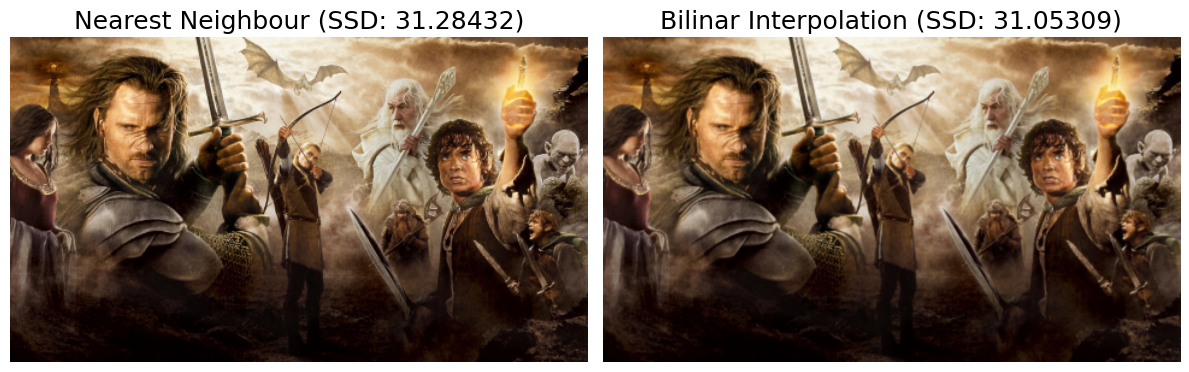

In [20]:
# Import images
im1 = cv.imread("images\\im01.png")
assert im1 is not None
im1_small = cv.imread("images\\im01small.png")
assert im1_small is not None

im1_zoomed_nn = zoom(im1_small, technique='nn')
im1_zoomed_bilinear = zoom(im1_small, technique='bilinear')

nn_SSD = norm_SSD(im1, im1_zoomed_nn)
bilinear_SSD = norm_SSD(im1, im1_zoomed_bilinear)

print('Normalized SSD for Nearest Neighbour: ', nn_SSD)
print('Normalized SSD for Bilinear: ', bilinear_SSD)

# Create a figure and axes
fig, axs = plt.subplots(1, 2, figsize=(12, 8))

# Plot the second image
axs[0].imshow(cv.cvtColor(im1_zoomed_nn, cv.COLOR_BGR2RGB))
axs[0].set_title(f'Nearest Neighbour (SSD: {nn_SSD:.5f})', fontsize=18)
axs[0].axis('off')  # Turn off the axis

# Plot the second image
axs[1].imshow(cv.cvtColor(im1_zoomed_bilinear, cv.COLOR_BGR2RGB))
axs[1].set_title(f'Bilinar Interpolation (SSD: {bilinear_SSD:.5f})', fontsize=18)
axs[1].axis('off')  # Turn off the axis

# Show the plot
plt.tight_layout()
plt.show()

<h3>Image 2</h3>

Normalized SSD for Nearest Neighbour:  11.902013310185184
Normalized SSD for Bilinear:  10.682991753472223


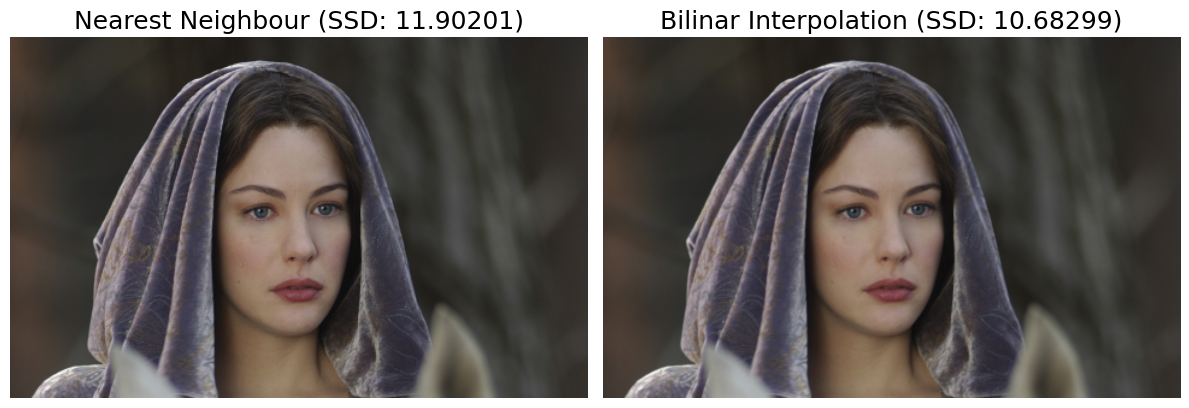

In [21]:
# Import images
im1 = cv.imread("images\\im02.png")
assert im1 is not None
im1_small = cv.imread("images\\im02small.png")
assert im1_small is not None

im1_zoomed_nn = zoom(im1_small, technique='nn')
im1_zoomed_bilinear = zoom(im1_small, technique='bilinear')

nn_SSD = norm_SSD(im1, im1_zoomed_nn)
bilinear_SSD = norm_SSD(im1, im1_zoomed_bilinear)

print('Normalized SSD for Nearest Neighbour: ', nn_SSD)
print('Normalized SSD for Bilinear: ', bilinear_SSD)

# Create a figure and axes
fig, axs = plt.subplots(1, 2, figsize=(12, 8))

# Plot the second image
axs[0].imshow(cv.cvtColor(im1_zoomed_nn, cv.COLOR_BGR2RGB))
axs[0].set_title(f'Nearest Neighbour (SSD: {nn_SSD:.5f})', fontsize=18)
axs[0].axis('off')  # Turn off the axis

# Plot the second image
axs[1].imshow(cv.cvtColor(im1_zoomed_bilinear, cv.COLOR_BGR2RGB))
axs[1].set_title(f'Bilinar Interpolation (SSD: {bilinear_SSD:.5f})', fontsize=18)
axs[1].axis('off')  # Turn off the axis

# Show the plot
plt.tight_layout()
plt.show()

## Question 9

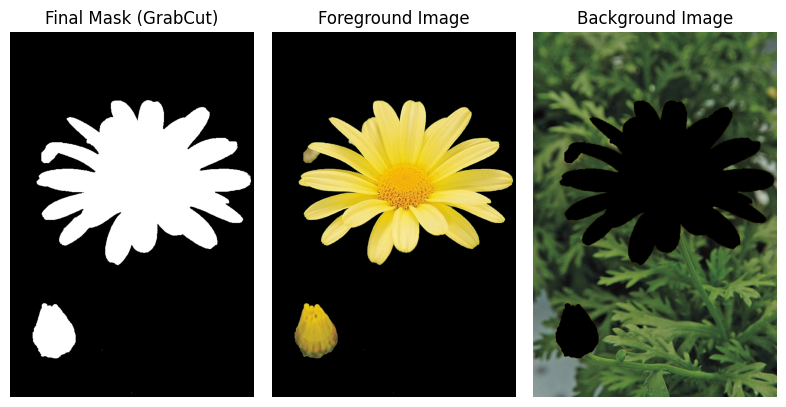

In [41]:
# Load image and convert to RGB
img = cv.imread("images\\q9.jpeg")  
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
h, w = img.shape[:2]

# Initialize mask and GrabCut models
mask = np.zeros((h, w), np.uint8)
bgd_model = np.zeros((1, 65), np.float64)
fgd_model = np.zeros((1, 65), np.float64)

# Define bounding box around the foreground object [x, y, w, h]
rect = (int(w * 0.01), int(h * 0.01), int(w * 0.98), int(h * 0.98))

# Run GrabCut algorithm with rectangle initialization
cv.grabCut(img, mask, rect, bgd_model, fgd_model, 5, cv.GC_INIT_WITH_RECT)

fg_mask = np.where((mask == cv.GC_FGD) | (mask == cv.GC_PR_FGD), 1, 0).astype('uint8')
bg_mask = 1 - fg_mask

# Isolate foreground and background components
foreground = cv.bitwise_and(img_rgb, img_rgb, mask=fg_mask)
background = cv.bitwise_and(img_rgb, img_rgb, mask=bg_mask)

fig, ax = plt.subplots(1, 3, figsize=(8, 4))
ax[0].imshow(fg_mask, cmap='gray'); ax[0].set_title('Final Mask (GrabCut)'); ax[0].axis('off')
ax[1].imshow(foreground); ax[1].set_title('Foreground Image'); ax[1].axis('off')
ax[2].imshow(background); ax[2].set_title('Background Image'); ax[2].axis('off')
plt.tight_layout()
plt.show()

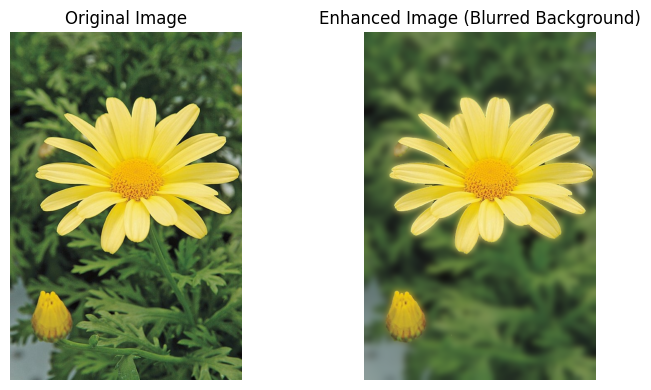

In [40]:

blurred_full = cv.GaussianBlur(img_rgb, (51, 51), 0)
# Combine sharp foreground with blurred background
enhanced_img = np.where(fg_mask[:, :, None] == 1, img_rgb, blurred_full)

fig,ax = plt.subplots(1,2,figsize = (8,4))
ax[0].imshow(img_rgb)
ax[0].set_title('Original Image')
ax[0].axis('off')
ax[1].imshow(enhanced_img)
ax[1].set_title('Enhanced Image (Blurred Background)')
ax[1].axis('off')
plt.tight_layout()
plt.show()

### Reason for the Dark Background Just Beyond the Edge of the Flower

The dark area that appears just outside the edge of the flower is caused by the way the background is blurred using a Gaussian kernel. When the foreground is removed from the background image, those foreground pixels are replaced with zero (black) values. Since Gaussian blur works by averaging nearby pixels, the black pixels around the flower’s boundary get mixed with the actual background pixels. As a result, the pixels near the edge become darker, creating a visible dark halo around the flower.


## Question 10

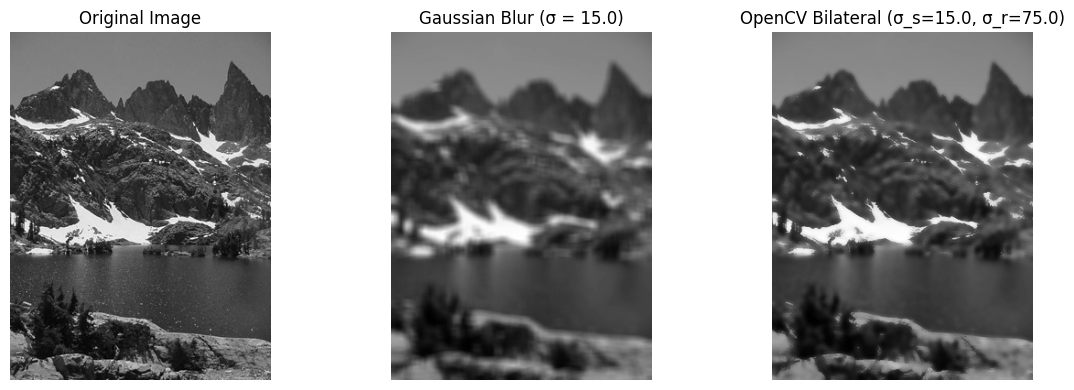

In [49]:
img = cv.imread("images\\q10.jpeg", cv.IMREAD_GRAYSCALE) 
assert img is not None, "Image not found."

sigma_s = 15.0  # Spatial Gaussian standard deviation
sigma_r = 75.0  # Range/Intensity Gaussian standard deviation
d = 9           # Neighborhood diameter 


gaussian_blurred = cv.GaussianBlur(img, (d, d), sigmaX=sigma_s, sigmaY=sigma_s)
cv_bilateral = cv.bilateralFilter(img, d=d, sigmaColor=sigma_r, sigmaSpace=sigma_s)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(img, cmap='gray'); axes[0].set_title('Original Image'); axes[0].axis('off')
axes[1].imshow(gaussian_blurred, cmap='gray'); axes[1].set_title(f'Gaussian Blur (σ = {sigma_s})'); axes[1].axis('off')
axes[2].imshow(cv_bilateral, cmap='gray'); axes[2].set_title(f'OpenCV Bilateral (σ_s={sigma_s}, σ_r={sigma_r})'); axes[2].axis('off')

plt.tight_layout()
plt.show()

In [53]:
def custom_bilateral_filter(img, d, sigma_s, sigma_r):
   
    img_float = img.astype(np.float64)
    h, w = img.shape
    radius = d // 2
    
    # Pad image to handle border pixels cleanly
    padded = np.pad(img_float, radius, mode='reflect')
    output = np.zeros_like(img_float)
    
    # Pre-compute Spatial Gaussian Kernel
    y_grid, x_grid = np.mgrid[-radius:radius+1, -radius:radius+1]
    spatial_kernel = np.exp(-(x_grid**2 + y_grid**2) / (2.0 * sigma_s**2))
    
    # Process each pixel
    for i in range(h):
        for j in range(w):
            # Extract neighborhood window
            window = padded[i:i + 2 * radius + 1, j:j + 2 * radius + 1]
            
            # Compute Range/Intensity Gaussian Kernel
            intensity_diff = window - img_float[i, j]
            range_kernel = np.exp(-(intensity_diff**2) / (2.0 * sigma_r**2))
            
            # Combine weights and normalize
            weights = spatial_kernel * range_kernel
            output[i, j] = np.sum(weights * window) / np.sum(weights)
            
    return np.clip(output, 0, 255).astype(img.dtype)

# Run custom implementation
custom_bilateral = custom_bilateral_filter(img, d=d, sigma_s=sigma_s, sigma_r=sigma_r)

Quantitative Comparison (Custom vs OpenCV Bilateral Filter):
 - Mean Squared Error (MSE): 8.6683
 - Peak Signal-to-Noise Ratio (PSNR): 38.75 dB


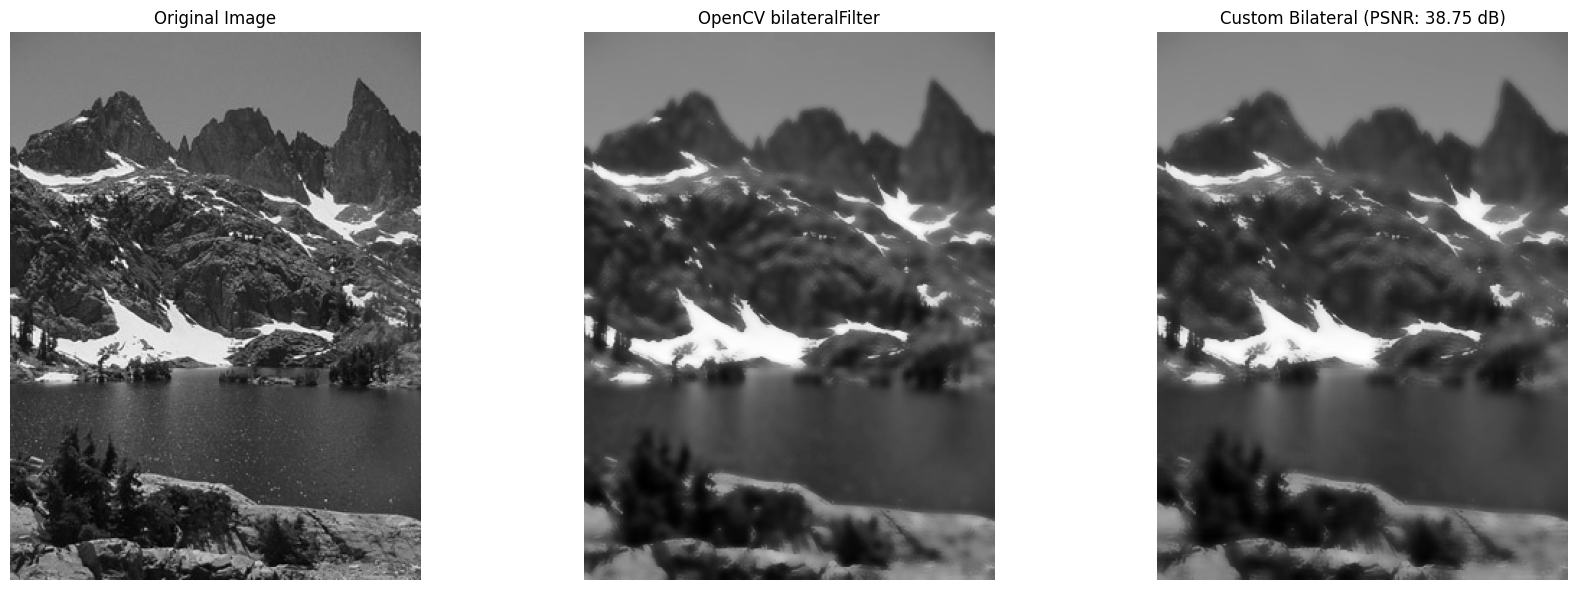

In [52]:
# Calculate MSE and PSNR
mse = np.mean((cv_bilateral.astype(np.float64) - custom_bilateral.astype(np.float64)) ** 2)
psnr = 10 * np.log10((255.0 ** 2) / mse) if mse > 0 else float('inf')

print(f"Quantitative Comparison (Custom vs OpenCV Bilateral Filter):")
print(f" - Mean Squared Error (MSE): {mse:.4f}")
print(f" - Peak Signal-to-Noise Ratio (PSNR): {psnr:.2f} dB")


fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(img, cmap='gray'); axes[0].set_title('Original Image'); axes[0].axis('off')
axes[1].imshow(cv_bilateral, cmap='gray'); axes[1].set_title('OpenCV bilateralFilter'); axes[1].axis('off')
axes[2].imshow(custom_bilateral, cmap='gray'); axes[2].set_title(f'Custom Bilateral (PSNR: {psnr:.2f} dB)'); axes[2].axis('off')

plt.tight_layout()
plt.show()

## Bilateral Filter Quantitative Analysis & Comparison

A **PSNR of 38.75 dB** confirms that the custom bilateral filter closely matches the OpenCV implementation. The small differences are mainly due to OpenCV's optimized calculations and differences in boundary padding.

Unlike Gaussian blur, which smooths pixels mainly based on spatial distance, the **bilateral filter considers both spatial distance and intensity differences**. This allows it to reduce noise while preserving important edges, such as mountain contours and shorelines.


### GitHub Repository

The complete code and related files are available in the GitHub repository:

[View the GitHub Repository](https://github.com/ChamodLD/Image-Processing-and-Machine-Vision)